In [ ]:
import bigframes.pandas as bf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
!pip install pyfonts
from pyfonts import load_google_font

# Load the DM Sans font (Google Font)
font = load_google_font("DM Sans")
font.set_size(11)

bf.options.bigquery.location = "EU" #this variable is set based on the dataset you chose to query
bf.options.bigquery.project = "macro-dreamer-406710" #this variable is set based on the dataset you chose to query

# df = bf.read_gbq('macro-dreamer-406710.wrp_raw.wrp_23_raw').to_pandas()

In [ ]:
# PREDICTION 1 TO EVALUATE: Perceptions of safety are likely to get worse in the next two years
# CREATING A COMBINED VERSION OF WRP DATASET
from google.cloud import bigquery

client = bigquery.Client()

query = """
with _2019 as (
  select
    "2019" as year,
    WPID_RANDOM as wpid,
    projection_weight as weight,
    countrynew as country,
    Gender as sex,
    L2 as more_less_safe,
    L6A as food_harm_worry,
    L6B as water_harm_worry,
    L6C as crime_harm_worry,
    L6D as weather_harm_worry,
    L6G as mental_harm_worry,
    L8A as food_harm_experienced,
    L8B as water_harm_experienced,
    L8C as crime_harm_experienced,
    L8D as weather_harm_experienced,
    L8G as mental_harm_experienced,
    L19 as work_injury
  from `macro-dreamer-406710.wrp_raw.wrp_19_raw`
),
_2021 as (
  select
    "2021" as year,
    WPID_RANDOM as wpid,
    PROJWT_2021 as weight,
    COUNTRYNEW as country,
    WP1219 as sex,
    WP20711 as more_less_safe,
    WP20720 as food_harm_worry,
    WP20721 as water_harm_worry,
    WP20722 as crime_harm_worry,
    WP20723 as weather_harm_worry,
    WP20726 as mental_harm_worry,
    WP22442 as food_harm_experienced,
    WP22443 as water_harm_experienced,
    WP22444 as crime_harm_experienced,
    WP22445 as weather_harm_experienced,
    WP22447 as mental_harm_experienced,
    WP22448 as work_injury
  from `macro-dreamer-406710.wrp_raw.wrp_21_raw`
),
_2023 as (
  select
    "2023" as year,
    WPID_RANDOM as wpid,
    WGT as weight,
    COUNTRYNEW as country,
    WP1219 as sex,
    WP20711 as more_less_safe,
    WP20720 as food_harm_worry,
    WP20721 as water_harm_worry,
    WP20722 as crime_harm_worry,
    WP20723 as weather_harm_worry,
    WP20726 as mental_harm_worry,
    WP22442 as food_harm_experienced,
    WP22443 as water_harm_experienced,
    WP22444 as crime_harm_experienced,
    WP22445 as weather_harm_experienced,
    WP22447 as mental_harm_experienced,
    WP22448 as work_injury
  from `macro-dreamer-406710.wrp_raw.wrp_23_raw`
)
select * from _2019
union all
select * from _2021
union all
select * from _2023
"""

# This always returns a pandas DataFrame
all_waves_df = client.query(query).to_dataframe()

all_waves_df.head()


,year,wpid,weight,country,sex,more_less_safe,food_harm_worry,water_harm_worry,crime_harm_worry,weather_harm_worry,mental_harm_worry,food_harm_experienced,water_harm_experienced,crime_harm_experienced,weather_harm_experienced,mental_harm_experienced,work_injury
0,2019,113808963.0,2326.277147,Chad,Male,Less safe,Very worried,Not worried,Very worried,Very worried,Very worried,Yes,No,Yes,No,Yes,
1,2019,119430831.0,1594.446743,Chad,Male,Less safe,Very worried,Somewhat worried,Somewhat worried,Very worried,Very worried,No,Yes,No,No,Yes,
2,2019,120944070.0,2198.329489,Chad,Male,About as safe,Very worried,Very worried,Somewhat worried,Somewhat worried,Very worried,No,No,No,Yes,No,
3,2019,124184902.0,15944.467430,Chad,Female,About as safe,Not worried,Somewhat worried,Very worried,Very worried,Very worried,Yes,Yes,Yes,Yes,Yes,
4,2019,124196860.0,1594.446743,Chad,Male,Less safe,Very worried,Very worried,Very worried,Very worried,Very worried,Yes,Yes,No,Yes,Yes,


In [ ]:
#APPLYING WEIGHTS

# Cleaning & Preparing
all_waves_df['weight'] = pd.to_numeric(all_waves_df['weight'], errors='coerce')
all_waves_df['more_less_safe'] = all_waves_df['more_less_safe'].fillna('No Response')
all_waves_df['more_less_safe'] = all_waves_df['more_less_safe'].replace(
    {'': 'No Response', ' ': 'No Response', '(DK)': "Don't know", '(Refused)': 'Refused'}
)
all_waves_df = all_waves_df.dropna(subset=['country','weight'])


# Filtering out unwanted responses
# unwanted_responses = ['No Response', '(DK)', '(Refused)']
# all_waves_df = all_waves_df[~all_waves_df['more_less_safe'].isin(unwanted_responses)]

# Weighted distribution function
def weighted_distribution(df, response_col, weight_col):
    dist = (
        df.groupby(response_col, dropna=False)[weight_col]
        .sum()
        .reset_index()
    )
    dist["percent"] = 100 * dist[weight_col] / dist[weight_col].sum()
    return dist

# Calculate distributions by year
results = []
for year, group in all_waves_df.groupby("year"):
    dist = weighted_distribution(group, "more_less_safe", "weight")
    dist["year"] = year
    results.append(dist)

results_df = pd.concat(results)

# Show long-format results
print(results_df)

# Pivot for easier comparison
pivot = results_df.pivot(index="more_less_safe", columns="year", values="percent")
print(pivot.round(1))


  more_less_safe        weight    percent  year
0  About as safe  1.939102e+09  36.167759  2019
1     Don't know  1.308070e+08   2.439788  2019
2      Less safe  1.337520e+09  24.947170  2019
3      More safe  1.946021e+09  36.296820  2019
4        Refused  7.959681e+06   0.148462  2019
0  About as safe  1.564209e+09  29.422800  2021
1     Don't know  4.360145e+07   0.820144  2021
2      Less safe  1.414576e+09  26.608202  2021
3      More safe  1.138905e+09  21.422813  2021
4    No Response  1.148859e+09  21.610047  2021
5        Refused  6.166602e+06   0.115994  2021
0  About as safe  6.081263e+04  41.394480  2023
1     Don't know  1.634661e+03   1.112696  2023
2      Less safe  4.603199e+04  31.333459  2023
3      More safe  3.823491e+04  26.026077  2023
4        Refused  1.958128e+02   0.133288  2023
year            2019  2021  2023
more_less_safe                  
About as safe   36.2  29.4  41.4
Don't know       2.4   0.8   1.1
Less safe       24.9  26.6  31.3
More safe       36.

##### Explanation of Weighting Function
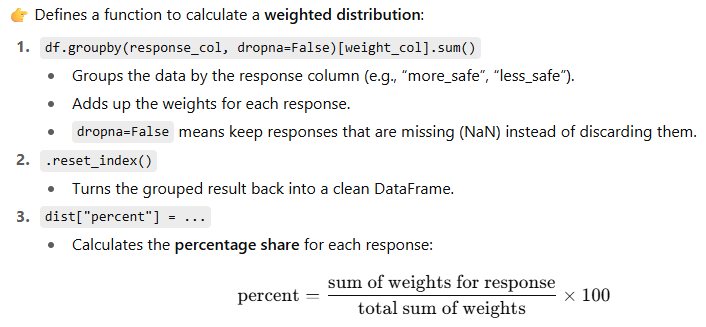

In [ ]:
# Table that's been created
pivot

year,2019,2021,2023
more_less_safe,,,
About as safe,36.167759,29.422800,41.394480
Don't know,2.439788,0.820144,1.112696
Less safe,24.947170,26.608202,31.333459
More safe,36.296820,21.422813,26.026077
No Response,NaN,21.610047,NaN
Refused,0.148462,0.115994,0.133288


* Less safe responses have increased yoy
* About as safe responses were stagnant before increasing the highest level in 2023
* More safe responses; 10 percentage point decline

In [ ]:
# RESPONSE DISTRIBUTION: In general, how WORRIED are you that each of the following things could cause you serious harm?
## AGGREGATION OF WORRIES ABOUT HARM & CALCULATION OF WEIGHTED PERCENTAGES

# Ensure weight column is numeric type
all_waves_df['weight'] = pd.to_numeric(all_waves_df['weight'], errors='coerce')

# Renaming the worry columns for easier handling
all_waves_df.rename(columns={
    'food_harm_worry': 'food',
    'water_harm_worry': 'water',
    'crime_harm_worry': 'violent_crime',
    'WP22213': 'road_accidents',
    'WP22214': 'work',
    'WP20726': 'mental_health',
    'WP24175': 'air',
    'WP20723': 'severe_weather',
    'WP24174': 'prolonged_severe_weather',
    'WP24173': 'wildfires'
}, inplace=True)

# outlining all responses to the worry question
worry_cols = [
    "food",
    "water",
    "violent_crime",
    "road_accidents",
    "work",
    "mental_health",
    "air",
    "severe_weather",
    "prolonged_severe_weather",
    "wildfires"
]

worry_df = df[worry_cols]

# Define weight variable
weights = df["WGT"]  # ← replace with your actual weight column

# Define response categories
worried_values = ["Very worried", "Somewhat worried"]
valid_values = ["Very worried", "Somewhat worried", "Not worried"]

# Weighted worried counts
worried_weighted = (
    worry_df.isin(worried_values)
    .multiply(weights, axis=0)
    .sum()
)

# Use full weighted denominator (includes DK/Refused)
total_weighted = weights.sum()

# Weighted percentages
worried_percent_weighted = (
    worried_weighted / total_weighted * 100
).round(1)

# Summary table
summary_table = pd.DataFrame({
    "Weighted_Worried_Count": worried_weighted,
    "Weighted_Worried_Percent": worried_percent_weighted
})

summary_table.sort_values(by="Weighted_Worried_Percent", ascending=False)

plot_df = (
    summary_table
        .reset_index()
        .rename(columns={"index": "Risk",
                         "Weighted_Worried_Percent": "proportion"})
        .sort_values(by="proportion", ascending=False)
        .reset_index(drop=True)
)
print(plot_df)

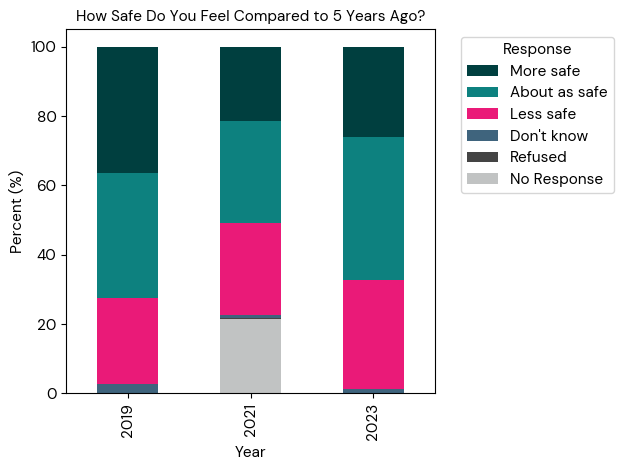

In [ ]:
# STACKED BAR PLOT OF SAFETY RESPONSES OVER THE YEARS (ALL RESPONSES KEPT)

# Load colors
colors=['#c1c3c3', '#444444', '#3f647d', '#ea1a78', '#0d817f', '#003f3f']

# Wide-format pivot table
pivot = results_df.pivot(index='year', columns='more_less_safe', values='percent')

# Ensure year is treated as a categorical variable for correct order
results_df['year'] = results_df['year'].astype(str)

# Column ordering
order = ['No Response', 'Refused', "Don't know", 'Less safe', 'About as safe', 'More safe']
pivot = pivot.reindex(columns=[c for c in order if c in pivot.columns])

# Create stacked bar plot
ax = pivot.plot(
    kind='bar',
    stacked=True,
    color=colors
)

# Apply DM Sans font everywhere
ax.set_title("How Safe Do You Feel Compared to 5 Years Ago?", fontproperties=font)
ax.set_ylabel('Percent (%)', fontproperties=font)
ax.set_xlabel('Year', fontproperties=font)

# reorder legend to match visual stacking (top-to-bottom)
handles, labels = ax.get_legend_handles_labels()
order = ['No Response', 'Refused', "Don't know", 'Less safe', 'About as safe', 'More safe']
handles = [handles[labels.index(o)] for o in order if o in labels]
labels = [o for o in order if o in labels]

# reverse order for top-to-bottom match
handles, labels = handles[::-1], labels[::-1]

# Legend with DM Sans font
ax.legend(
    handles,
    labels,
    title='Response',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    prop=font,
    title_fontproperties=font
)

# Apply DM Sans to tick labels
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(font)

plt.tight_layout()
plt.show()


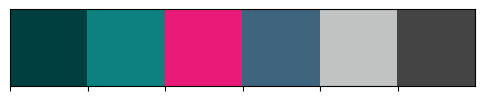

In [ ]:
#visualising foundation color palette
colors=['#003f3f', '#0d817f','#ea1a78','#3f647d','#c1c3c3', '#444444']
sns.palplot(colors)

In [ ]:
# MAPPING THE COUNTRIES IN THE DF TO REGIONS & CREATING A REGIONAL COLUMN
country_to_region = {
    # Eastern Africa
    "Rwanda": "Eastern Africa", "Uganda": "Eastern Africa", "Ethiopia": "Eastern Africa",
    "Kenya": "Eastern Africa", "Tanzania": "Eastern Africa", "Somalia": "Eastern Africa",
    "Comoros": "Eastern Africa", "Madagascar": "Eastern Africa", "Malawi": "Eastern Africa",
    "Mozambique": "Eastern Africa", "Zambia": "Eastern Africa", "Zimbabwe": "Eastern Africa",
    "Mauritius": "Eastern Africa",

    # Central/Western Africa
    "Chad": "Central/Western Africa", "Gabon": "Central/Western Africa",
    "Ghana": "Central/Western Africa", "Niger": "Central/Western Africa",
    "Gambia": "Central/Western Africa", "Nigeria": "Central/Western Africa",
    "Liberia": "Central/Western Africa", "Ivory Coast": "Central/Western Africa",
    "Sierra Leone": "Central/Western Africa", "Cameroon": "Central/Western Africa",
    "Burkina Faso": "Central/Western Africa", "Congo Brazzaville": "Central/Western Africa",
    "Congo Kinshasa": "Central/Western Africa", "Mauritania": "Central/Western Africa",
    "Guinea": "Central/Western Africa", "Mali": "Central/Western Africa",
    "Benin": "Central/Western Africa", "Togo": "Central/Western Africa",
    "Senegal": "Central/Western Africa",

    # Northern Africa
    "Morocco": "Northern Africa", "Tunisia": "Northern Africa", "Algeria": "Northern Africa",
    "Libya": "Northern Africa", "Egypt": "Northern Africa",

    # Southern Africa
    "Botswana": "Southern Africa", "South Africa": "Southern Africa",
    "Namibia": "Southern Africa", "Lesotho": "Southern Africa",
    "Eswatini": "Southern Africa",

    # Latin America & the Caribbean
    "Chile": "Latin America & the Caribbean", "Mexico": "Latin America & the Caribbean",
    "Panama": "Latin America & the Caribbean", "Ecuador": "Latin America & the Caribbean",
    "Uruguay": "Latin America & the Caribbean", "Colombia": "Latin America & the Caribbean",
    "Honduras": "Latin America & the Caribbean", "Paraguay": "Latin America & the Caribbean",
    "Venezuela": "Latin America & the Caribbean", "Argentina": "Latin America & the Caribbean",
    "Guatemala": "Latin America & the Caribbean", "Nicaragua": "Latin America & the Caribbean",
    "El Salvador": "Latin America & the Caribbean", "Dominican Republic": "Latin America & the Caribbean",
    "Peru": "Latin America & the Caribbean", "Jamaica": "Latin America & the Caribbean",
    "Bolivia": "Latin America & the Caribbean", "Costa Rica": "Latin America & the Caribbean",
    "Brazil": "Latin America & the Caribbean",

    # Northern America
    "United States": "Northern America", "Canada": "Northern America",

    # Central Asia
    "Kazakhstan": "Central Asia", "Kyrgyzstan": "Central Asia",
    "Turkmenistan": "Central Asia", "Uzbekistan": "Central Asia",
    "Tajikistan": "Central Asia",

    # Eastern Asia
    "China": "Eastern Asia", "Hong Kong": "Eastern Asia",
    "Taiwan": "Eastern Asia", "South Korea": "Eastern Asia",
    "Japan": "Eastern Asia", "Mongolia": "Eastern Asia",

    # Southeastern Asia
    "Thailand": "Southeastern Asia", "Myanmar": "Southeastern Asia",
    "Vietnam": "Southeastern Asia", "Laos": "Southeastern Asia",
    "Singapore": "Southeastern Asia", "Cambodia": "Southeastern Asia",
    "Malaysia": "Southeastern Asia", "Indonesia": "Southeastern Asia",
    "Philippines": "Southeastern Asia",

    # Southern Asia
    "India": "Southern Asia", "Pakistan": "Southern Asia",
    "Sri Lanka": "Southern Asia", "Bangladesh": "Southern Asia",
    "Afghanistan": "Southern Asia", "Nepal": "Southern Asia",

    # Middle East
    "Yemen": "Middle East", "Palestine": "Middle East",
    "Iran": "Middle East", "Cyprus": "Middle East",
    "Kuwait": "Middle East", "Bahrain": "Middle East",
    "United Arab Emirates": "Middle East", "Israel": "Middle East",
    "Iraq": "Middle East", "Saudi Arabia": "Middle East",
    "Jordan": "Middle East", "Lebanon": "Middle East",
    "Armenia": "Middle East", "Georgia": "Middle East",
    "Azerbaijan": "Middle East", "Turkey": "Middle East",

    # Eastern Europe
    "Russia": "Eastern Europe", "Ukraine": "Eastern Europe",
    "Moldova": "Eastern Europe", "Romania": "Eastern Europe",
    "Bulgaria": "Eastern Europe", "Belarus": "Eastern Europe",
    "Czech Republic": "Eastern Europe", "Poland": "Eastern Europe",
    "Slovakia": "Eastern Europe", "Hungary": "Eastern Europe",

    # Northern/Western Europe
    "Estonia": "Northern/Western Europe", "Ireland": "Northern/Western Europe",
    "Latvia": "Northern/Western Europe", "Lithuania": "Northern/Western Europe",
    "Luxembourg": "Northern/Western Europe", "Sweden": "Northern/Western Europe",
    "Denmark": "Northern/Western Europe", "United Kingdom": "Northern/Western Europe",
    "Germany": "Northern/Western Europe", "Norway": "Northern/Western Europe",
    "Finland": "Northern/Western Europe", "Iceland": "Northern/Western Europe",
    "Netherlands": "Northern/Western Europe", "France": "Northern/Western Europe",
    "Belgium": "Northern/Western Europe", "Switzerland": "Northern/Western Europe",

    # Southern Europe
    "Malta": "Southern Europe", "Slovenia": "Southern Europe",
    "North Macedonia": "Southern Europe", "Italy": "Southern Europe",
    "Spain": "Southern Europe", "Bosnia Herzegovina": "Southern Europe",
    "Serbia": "Southern Europe", "Kosovo": "Southern Europe",
    "Albania": "Southern Europe", "Croatia": "Southern Europe",
    "Portugal": "Southern Europe", "Montenegro": "Southern Europe",
    "Greece": "Southern Europe", "Austria": "Southern Europe",

    # Australia & New Zealand
    "Australia": "Australia & New Zealand", "New Zealand": "Australia & New Zealand"
}

all_waves_df['region'] = all_waves_df['country'].map(country_to_region)
all_waves_df.head()


,year,wpid,weight,country,sex,more_less_safe,food_harm_worry,water_harm_worry,crime_harm_worry,weather_harm_worry,mental_harm_worry,food_harm_experienced,water_harm_experienced,crime_harm_experienced,weather_harm_experienced,mental_harm_experienced,work_injury,region
0,2019,113808963.0,2326.277147,Chad,Male,Less safe,Very worried,Not worried,Very worried,Very worried,Very worried,Yes,No,Yes,No,Yes,,Central/Western Africa
1,2019,119430831.0,1594.446743,Chad,Male,Less safe,Very worried,Somewhat worried,Somewhat worried,Very worried,Very worried,No,Yes,No,No,Yes,,Central/Western Africa
2,2019,120944070.0,2198.329489,Chad,Male,About as safe,Very worried,Very worried,Somewhat worried,Somewhat worried,Very worried,No,No,No,Yes,No,,Central/Western Africa
3,2019,124184902.0,15944.467430,Chad,Female,About as safe,Not worried,Somewhat worried,Very worried,Very worried,Very worried,Yes,Yes,Yes,Yes,Yes,,Central/Western Africa
4,2019,124196860.0,1594.446743,Chad,Male,Less safe,Very worried,Very worried,Very worried,Very worried,Very worried,Yes,Yes,No,Yes,Yes,,Central/Western Africa


In [ ]:
all_waves_df['region'].unique()

array(['Central/Western Africa', 'Middle East', 'Southeastern Asia',
       'Latin America & the Caribbean', 'Eastern Asia', 'Northern Africa',
       'Southern Asia', 'Southern Europe', 'Eastern Africa',
       'Northern America', 'Northern/Western Europe', 'Eastern Europe',
       'Australia & New Zealand', 'Southern Africa', 'Central Asia'],
      dtype=object)

In [ ]:
# CALCULATING WHICH REGION WAS MOSTLY TO FEEL LESS SAFE ACROSS THE POLL WAVES

# Step One: Filter to only less safe responses
less_safe_df = all_waves_df[all_waves_df['more_less_safe'] == 'Less safe']

# Step Two: Count less safe responses for each region for each year
region_year_counts = less_safe_df.groupby(['region', 'year']).size().reset_index(name='less_safe_count')

# Step Three: Count all responses per region per year
total_region_year  = all_waves_df.groupby(['region', 'year']).size().reset_index(name='total_count')

# Step Four: Merge & calculate proportions
merged_df = pd.merge(region_year_counts, total_region_year, on=['region', 'year'], how='outer')
merged_df['less_safe_proportion'] = merged_df['less_safe_count'] / merged_df['total_count']

# Step Five: Find top region each year
top_regions_each_year = (
    merged_df.loc[merged_df.groupby("year")["less_safe_proportion"].idxmax()]
    .reset_index(drop=True)
)

print(f"Top region by year (highest proportion of less safe responses):")
print(top_regions_each_year)

# Step 6: Testing Latin America prediction
latin_america_trend = merged_df[merged_df['region'] == 'Latin America & the Caribbean']

print("\nLatin America & the Carribean trend across years:")
print(latin_america_trend[['year', 'less_safe_proportion']])


Top region by year (highest proportion of less safe responses):
                          region  year  less_safe_count  total_count  \
0  Latin America & the Caribbean  2019             9343        19359   
1                Southern Africa  2021             1174         2027   
2                Southern Africa  2023             1921         4011   

   less_safe_proportion  
0              0.482618  
1              0.579181  
2              0.478933  

Latin America & the Carribean trend across years:
    year  less_safe_proportion
18  2019              0.482618
19  2021              0.429484
20  2023              0.432014


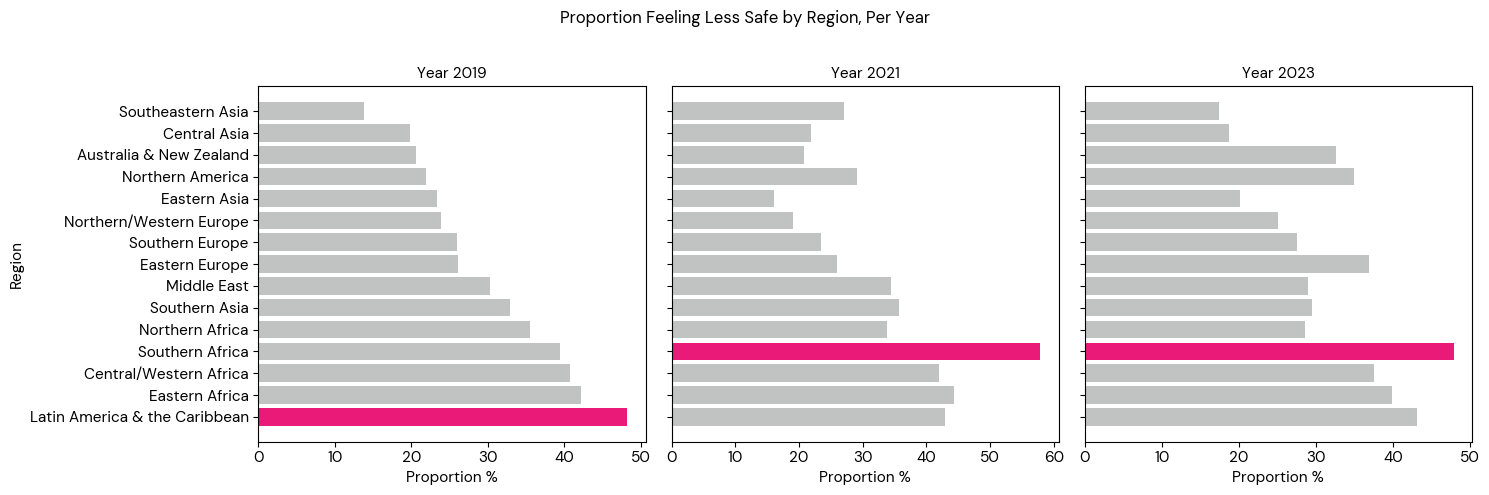

In [ ]:
# PLOTTING THE REGION MOST LIKELY TO FEEL LESS SAFE BY YEAR
merged_df['less_safe_percent'] = merged_df['less_safe_proportion'] * 100
years = sorted(merged_df['year'].unique())
fig, axes = plt.subplots(1, len(years), figsize=(15, 5), sharey=True)

for i, year in enumerate(years):
    ax = axes[i]
    year_data = merged_df[merged_df['year'] == year].sort_values("less_safe_percent", ascending=False)

    # Bar chart
    ax.barh(year_data["region"], year_data["less_safe_percent"], color="#c1c3c3")

    # Highlight the top region
    top_region = year_data.iloc[0]
    ax.barh(top_region["region"], top_region["less_safe_percent"], color="#ea1a78")

    # Formatting
    ax.set_title(f"Year {year}", fontproperties=font)
    ax.set_xlabel("Proportion %", fontproperties=font)
    if i == 0:  # only show y-axis labels on the first chart
        ax.set_ylabel("Region", fontproperties=font)
    else:
        ax.set_ylabel("")

# Setting font for tick labels
for ax in axes:
      for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontproperties(font)

plt.suptitle("Proportion Feeling Less Safe by Region, Per Year", fontproperties=font, fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
# RESPONSES TO MORE/LESS SAFE QUESTION FILTERED TO REGION MOST AFFECTED BY COVID
ee_df = all_waves_df[all_waves_df["region"] == "Eastern Europe"]

# Calculate distributions by year (same logic as before)
results = []
for year, group in ee_df.groupby("year"):
    dist = weighted_distribution(group, "more_less_safe", "weight")
    dist["year"] = year
    results.append(dist)

ee_results_df = pd.concat(results)

# Show long-format results
print(ee_results_df)

# Pivot for easier comparison
pivot_ee = ee_results_df.pivot(index="more_less_safe", columns="year", values="percent")
print(pivot_ee.round(1))


  more_less_safe        weight    percent  year
0  About as safe  1.306731e+08  55.406186  2019
1     Don't know  9.640628e+06   4.087685  2019
2      Less safe  4.945194e+07  20.967924  2019
3      More safe  4.579941e+07  19.419229  2019
4        Refused  2.805985e+05   0.118975  2019
0  About as safe  1.224717e+08  52.291623  2021
1     Don't know  2.748547e+06   1.173544  2021
2      Less safe  6.274271e+07  26.789197  2021
3      More safe  4.601583e+07  19.647336  2021
4        Refused  2.302268e+05   0.098300  2021
0  About as safe  5.237638e+03  52.167710  2023
1     Don't know  1.336571e+02   1.331246  2023
2      Less safe  3.494202e+03  34.802808  2023
3      More safe  1.168377e+03  11.637225  2023
4        Refused  6.125458e+00   0.061011  2023
year            2019  2021  2023
more_less_safe                  
About as safe   55.4  52.3  52.2
Don't know       4.1   1.2   1.3
Less safe       21.0  26.8  34.8
More safe       19.4  19.6  11.6
Refused          0.1   0.1   0.1


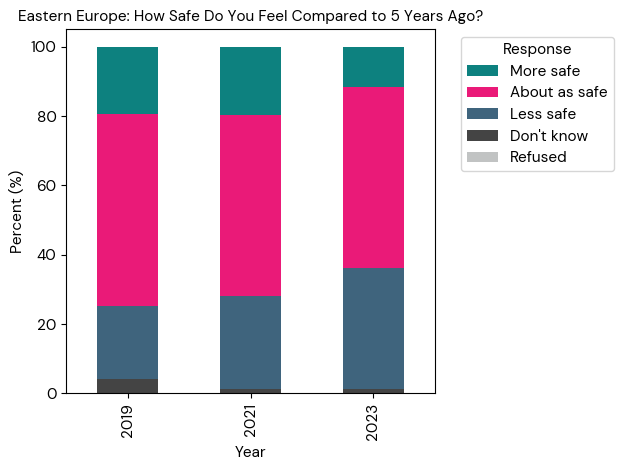

In [ ]:
# STACKED BAR PLOT OF EUROPEAN SAFETY RESPONSES OVER THE YEARS
colors=['#c1c3c3', '#444444', '#3f647d', '#ea1a78', '#0d817f', '#003f3f']
#wide format pivot table
pivot_ee =  ee_results_df.pivot(index='year', columns='more_less_safe', values='percent')

#ensures year is treated as categorical variable for the years to be in order
ee_results_df['year'] = ee_results_df['year'].astype(str)

#column ordering
order = ['No Response', 'Refused', "Don't know", 'Less safe', 'About as safe', 'More safe']
pivot_ee = pivot_ee.reindex(columns=[c for c in order if c in pivot_ee.columns])

# plot stacked bar
ax = pivot_ee.plot(
    kind='bar',
    stacked=True,
    color=colors,
)

# Apply DM Sans font everywhere
ax.set_title("Eastern Europe: How Safe Do You Feel Compared to 5 Years Ago?", fontproperties=font)
ax.set_ylabel('Percent (%)', fontproperties=font)
ax.set_xlabel('Year', fontproperties=font)

# reorder legend to match visual stacking (top-to-bottom)
handles, labels = ax.get_legend_handles_labels()
handles = [handles[labels.index(o)] for o in order if o in labels]
labels = [o for o in order if o in labels]

# reverse order for top-to-bottom match
handles, labels = handles[::-1], labels[::-1]

# Legend with DM Sans font
ax.legend(
    handles,
    labels,
    title='Response',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    prop=font,
    title_fontproperties=font
)

# Apply DM Sans to tick labels
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(font)

plt.tight_layout()
plt.show()

In [ ]:
# Prediction 3: People in Latin America and the Caribbean may be the most likely to feel less safe in 2020

latin_df = all_waves_df[all_waves_df["region"] == "Latin America & the Caribbean"]

# Calculate distributions by year (same logic as before)
results = []
for year, group in latin_df.groupby("year"):
    dist = weighted_distribution(group, "more_less_safe", "weight")
    dist["year"] = year
    results.append(dist)

latin_results_df = pd.concat(results)

# Show long-format results
print(latin_results_df)

# Pivot for easier comparison
pivot_latin = latin_results_df.pivot(index="more_less_safe", columns="year", values="percent")
print(pivot_latin.round(1))


  more_less_safe        weight    percent  year
0  About as safe  1.137770e+08  25.069300  2019
1     Don't know  3.084604e+06   0.679653  2019
2      Less safe  2.346672e+08  51.705919  2019
3      More safe  1.017063e+08  22.409679  2019
4        Refused  6.147344e+05   0.135449  2019
0  About as safe  1.141096e+08  25.057126  2021
1     Don't know  2.135417e+06   0.468912  2021
2      Less safe  2.211220e+08  48.555813  2021
3      More safe  1.168873e+08  25.667087  2021
4        Refused  1.143326e+06   0.251061  2021
0  About as safe  5.548491e+03  30.806123  2023
1     Don't know  1.452676e+02   0.806549  2023
2      Less safe  7.354074e+03  40.831015  2023
3      More safe  4.894584e+03  27.175528  2023
4        Refused  6.858311e+01   0.380785  2023
year            2019  2021  2023
more_less_safe                  
About as safe   25.1  25.1  30.8
Don't know       0.7   0.5   0.8
Less safe       51.7  48.6  40.8
More safe       22.4  25.7  27.2
Refused          0.1   0.3   0.4


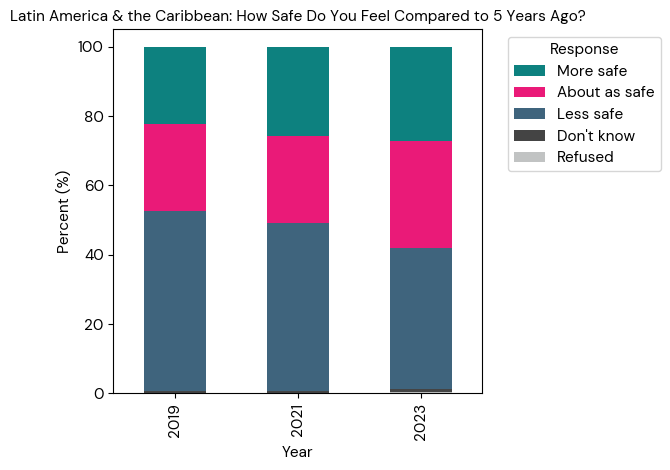

In [ ]:
# STACKED BAR PLOT OF LATIN AMERICA SAFETY RESPONSES OVER THE YEARS
colors=['#c1c3c3', '#444444', '#3f647d', '#ea1a78', '#0d817f', '#003f3f']
#wide format pivot table
pivot_latin =  latin_results_df.pivot(index='year', columns='more_less_safe', values='percent')

#ensures year is treated as categorical variable for the years to be in order
latin_results_df['year'] = latin_results_df['year'].astype(str)

#column ordering
order = ['No Response', 'Refused', "Don't know", 'Less safe', 'About as safe', 'More safe']
pivot_latin = pivot_latin.reindex(columns=[c for c in order if c in pivot_latin.columns])

# plot stacked bar
ax = pivot_latin.plot(
    kind='bar',
    stacked=True,
    color=colors,
)

# Apply DM Sans font everywhere
ax.set_title("Latin America & the Caribbean: How Safe Do You Feel Compared to 5 Years Ago?", fontproperties=font)
ax.set_ylabel('Percent (%)', fontproperties=font)
ax.set_xlabel('Year', fontproperties=font)

# reorder legend to match visual stacking (top-to-bottom)
handles, labels = ax.get_legend_handles_labels()
handles = [handles[labels.index(o)] for o in order if o in labels]
labels = [o for o in order if o in labels]

# reverse order for top-to-bottom match
handles, labels = handles[::-1], labels[::-1]

# Legend with DM Sans font
ax.legend(
    handles,
    labels,
    title='Response',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    prop=font,
    title_fontproperties=font
)

# Apply DM Sans to tick labels
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(font)

plt.tight_layout()
plt.show()


In [ ]:
# rest of the world (row) excluding Latin American for comparison

row_df = all_waves_df[all_waves_df["region"] != "Latin America & the Caribbean"]

# Calculate distributions by year (same logic as before)
results = []
for year, group in row_df.groupby("year"):
    dist = weighted_distribution(group, "more_less_safe", "weight")
    dist["year"] = year
    results.append(dist)

row_results_df = pd.concat(results)

# Show long-format results
print(row_results_df)

# Pivot for easier comparison
pivot_row = row_results_df.pivot(index="more_less_safe", columns="year", values="percent")
print(pivot_row.round(1))

  more_less_safe        weight    percent  year
0  About as safe  1.825325e+09  37.194142  2019
1     Don't know  1.277224e+08   2.602565  2019
2      Less safe  1.102853e+09  22.472528  2019
3      More safe  1.844315e+09  37.581099  2019
4        Refused  7.344946e+06   0.149666  2019
0  About as safe  1.450100e+09  29.831801  2021
1     Don't know  4.146603e+07   0.853049  2021
2      Less safe  1.193454e+09  24.552029  2021
3      More safe  1.022017e+09  21.025186  2021
4    No Response  1.148859e+09  23.634595  2021
5        Refused  5.023276e+06   0.103340  2021
0  About as safe  5.526414e+04  42.873986  2023
1     Don't know  1.489394e+03   1.155474  2023
2      Less safe  3.867791e+04  30.006370  2023
3      More safe  3.334033e+04  25.865465  2023
4        Refused  1.272297e+02   0.098705  2023
year            2019  2021  2023
more_less_safe                  
About as safe   37.2  29.8  42.9
Don't know       2.6   0.9   1.2
Less safe       22.5  24.6  30.0
More safe       37.

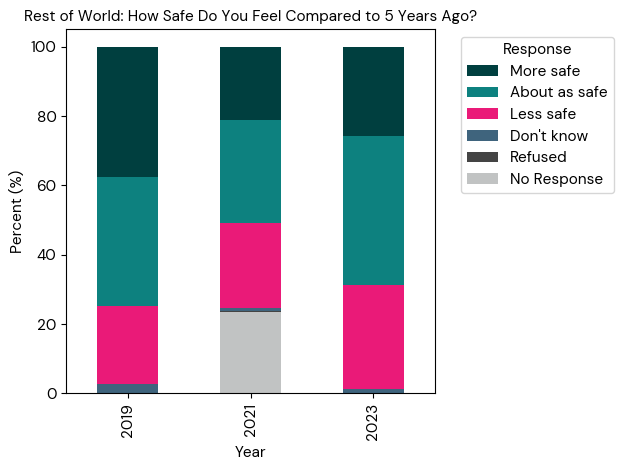

In [ ]:
#REST OF WORLD EXCLUDING LATIN AMERICA SAFETY RESPONSES OVER THE YEARS
colors=['#c1c3c3', '#444444', '#3f647d', '#ea1a78', '#0d817f', '#003f3f']
#wide format pivot table
pivot_row =  row_results_df.pivot(index='year', columns='more_less_safe', values='percent')

#ensures year is treated as categorical variable for the years to be in order
row_results_df['year'] = row_results_df['year'].astype(str)

#column ordering
order = ['No Response', 'Refused', "Don't know", 'Less safe', 'About as safe', 'More safe']
pivot_row = pivot_row.reindex(columns=[c for c in order if c in pivot_row.columns])

# plot stacked bar
ax = pivot_row.plot(
    kind='bar',
    stacked=True,
    color=colors,
)

# Apply DM Sans font everywhere
ax.set_title("Rest of World: How Safe Do You Feel Compared to 5 Years Ago?", fontproperties=font)
ax.set_ylabel('Percent (%)', fontproperties=font)
ax.set_xlabel('Year', fontproperties=font)

# reorder legend to match visual stacking (top-to-bottom)
handles, labels = ax.get_legend_handles_labels()
handles = [handles[labels.index(o)] for o in order if o in labels]
labels = [o for o in order if o in labels]

# reverse order for top-to-bottom match
handles, labels = handles[::-1], labels[::-1]

# Legend with DM Sans font
ax.legend(
    handles,
    labels,
    title='Response',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    prop=font,
    title_fontproperties=font
)

# Apply DM Sans to tick labels
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(font)

plt.tight_layout()
plt.show()

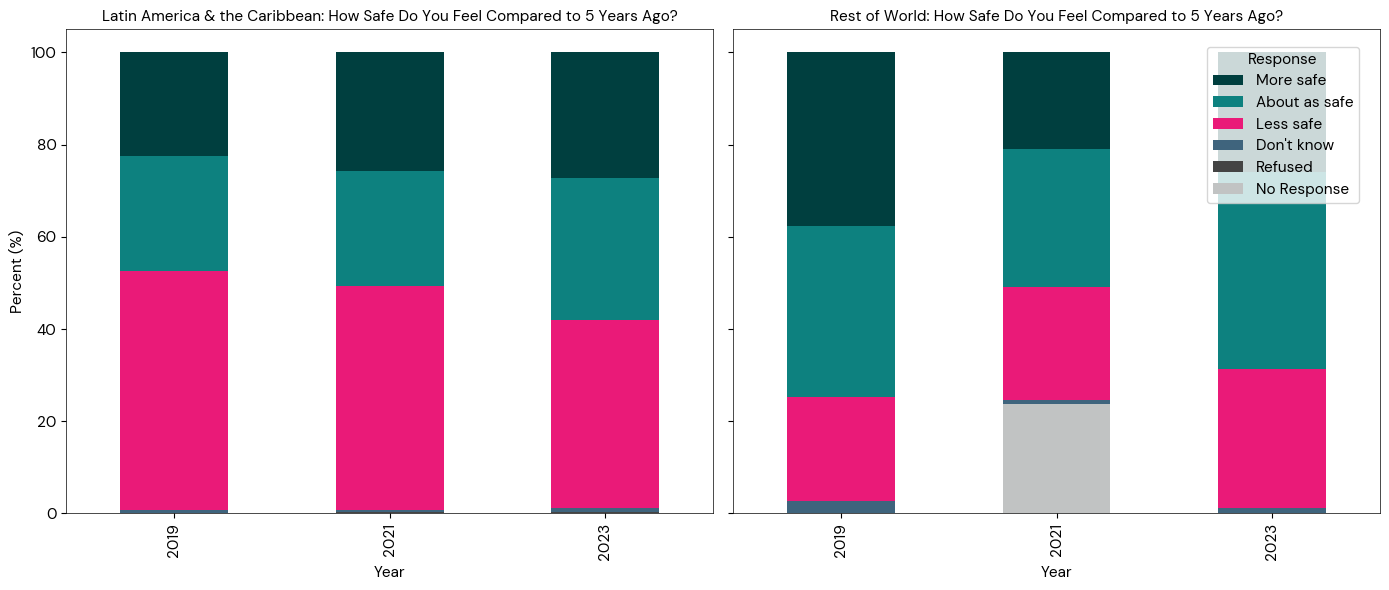

In [ ]:
# STACKED COMBINED LATIN AMERICA & REST OF WORLD FACET PLOT
# Common settings
colors=['#c1c3c3', '#444444', '#3f647d', '#ea1a78', '#0d817f', '#003f3f']
order = ['No Response', 'Refused', "Don't know", 'Less safe', 'About as safe', 'More safe']

# Ensure year is treated as categorical
latin_results_df['year'] = latin_results_df['year'].astype(str)
row_results_df['year'] = row_results_df['year'].astype(str)

# Pivot tables
pivot_latin = latin_results_df.pivot(index='year', columns='more_less_safe', values='percent')
pivot_row = row_results_df.pivot(index='year', columns='more_less_safe', values='percent')

# Add in empty no response column to sync plot colors
pivot_latin['No Response'] = 0

# Reorder columns
pivot_latin = pivot_latin.reindex(columns=[c for c in order if c in pivot_latin.columns])
pivot_row = pivot_row.reindex(columns=[c for c in order if c in pivot_row.columns])

# Create subplots: Latin America (left) | Rest of World (right)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# --- Latin America Plot ---
pivot_latin.plot(
    kind='bar',
    stacked=True,
    color=colors,
    ax=axes[0]
)
axes[0].set_title("Latin America & the Caribbean: How Safe Do You Feel Compared to 5 Years Ago?", fontproperties=font)
axes[0].set_ylabel('Percent (%)', fontproperties=font)
axes[0].set_xlabel('Year', fontproperties=font)

# --- Rest of World Plot ---
pivot_row.plot(
    kind='bar',
    stacked=True,
    color=colors,
    ax=axes[1]
)
axes[1].set_title("Rest of World: How Safe Do You Feel Compared to 5 Years Ago?", fontproperties=font)
axes[1].set_xlabel('Year', fontproperties=font)
axes[1].set_ylabel('', fontproperties=font)

# Remove individual legends
for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# --- Shared Legend ---
handles, labels = axes[1].get_legend_handles_labels()
handles = [handles[labels.index(o)] for o in order if o in labels]
labels = [o for o in order if o in labels]
handles, labels = handles[::-1], labels[::-1]

legend = axes[1].legend(
    handles,
    labels,
    title='Response',
    loc='upper right',                # top-right corner
    bbox_to_anchor=(0.98, 0.98),     # slightly inside plot
    frameon=True,
    prop=font,
    title_fontproperties=font
)

# --- Styling ---
for ax in axes:
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontproperties(font)
    # Thin black border
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_edgecolor('black')

plt.tight_layout()
plt.show()

In [ ]:
#PREDICTION 4 - HOW HAVE WORRY QUESTION RESPONSES CHANGED?
#checking indicator 1: food

# Filter out unwanted responses
# unwanted_responses = ['(DK)', '(Refused)']
# all_waves_df = all_waves_df[~all_waves_df['food_harm_worry'].isin(unwanted_responses)]

# Cleaning column
all_waves_df['food_harm_worry'] = all_waves_df['food_harm_worry'].replace(
    {'': 'No Response', ' ': 'No Response', '(DK)': "Don't know", '(Refused)': 'Refused'}
)

# Calculate distributions by year
food_worry_results = []
for year, group in all_waves_df.groupby("year"):
    dist = weighted_distribution(group, "food_harm_worry", "weight")
    dist["year"] = year
    food_worry_results.append(dist)

food_worry_df = pd.concat(food_worry_results)

# Show long-format results
print(food_worry_df)

# Pivot for easier comparison
pivot_foodworry = food_worry_df.pivot(index="food_harm_worry", columns="year", values="percent")
print(pivot_foodworry.round(1))


    food_harm_worry        weight    percent  year
0        Don't know  8.664918e+07   1.616164  2019
1       Not worried  2.041342e+09  38.074729  2019
2           Refused  4.511820e+06   0.084154  2019
3  Somewhat worried  2.127779e+09  39.686926  2019
4      Very worried  1.101128e+09  20.538026  2019
0        Don't know  4.174430e+07   0.785211  2021
1       Not worried  2.304651e+09  43.350508  2021
2           Refused  3.359691e+06   0.063196  2021
3  Somewhat worried  1.814551e+09  34.131732  2021
4      Very worried  1.152012e+09  21.669353  2021
0        Don't know  7.806549e+02   0.531383  2023
1       Not worried  6.580464e+04  44.792488  2023
2           Refused  7.258704e+01   0.049409  2023
3  Somewhat worried  4.874623e+04  33.181014  2023
4      Very worried  3.150589e+04  21.445706  2023
year              2019  2021  2023
food_harm_worry                   
Don't know         1.6   0.8   0.5
Not worried       38.1  43.4  44.8
Refused            0.1   0.1   0.0
Somewhat 

In [ ]:
#FOOD WORRY SUMS

worry_levels = ["Very worried", "Somewhat worried"]

totals = pivot_foodworry.loc[worry_levels].sum()

for year, total in totals.items():
    print(f"In {year}, {total:.2f}% of respondents were worried in some capacity about food harm.")

In 2019, 60.22% of respondents were worried in some capacity about food harm.
In 2021, 55.80% of respondents were worried in some capacity about food harm.
In 2023, 54.63% of respondents were worried in some capacity about food harm.


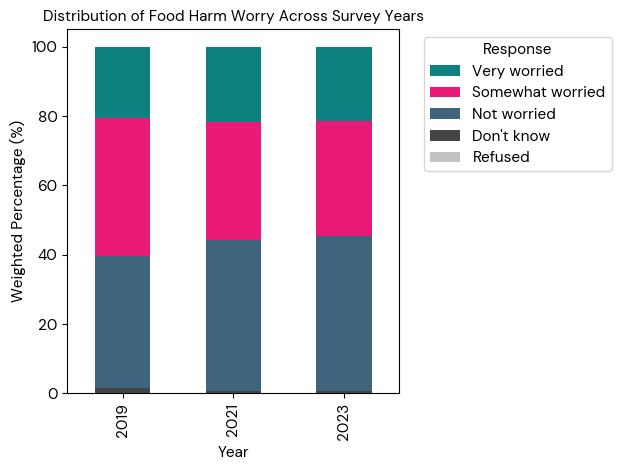

In [ ]:
# STACKED BAR PLOT OF FOOD WORRY
colors=['#c1c3c3', '#444444', '#3f647d', '#ea1a78', '#0d817f', '#003f3f']
#wide format pivot table
pivot_foodworry =  food_worry_df.pivot(index='year', columns='food_harm_worry', values='percent')

#ensures year is treated as categorical variable for the years to be in order
food_worry_df['year'] = food_worry_df['year'].astype(str)

#column ordering
order = ['No Response', 'Refused', "Don't know", 'Not worried', 'Somewhat worried', 'Very worried']
pivot_foodworry = pivot_foodworry.reindex(columns=[c for c in order if c in pivot_foodworry.columns])

# plot stacked bar
ax = pivot_foodworry.plot(
    kind='bar',
    stacked=True,
    color=colors,
)

# Apply DM Sans font everywhere
ax.set_title("Distribution of Food Harm Worry Across Survey Years", fontproperties=font)
ax.set_ylabel('Weighted Percentage (%)', fontproperties=font)
ax.set_xlabel('Year', fontproperties=font)

# reorder legend to match visual stacking (top-to-bottom)
handles, labels = ax.get_legend_handles_labels()
handles = [handles[labels.index(o)] for o in order if o in labels]
labels = [o for o in order if o in labels]

# reverse order for top-to-bottom match
handles, labels = handles[::-1], labels[::-1]

# Legend with DM Sans font
ax.legend(
    handles,
    labels,
    title='Response',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    prop=font,
    title_fontproperties=font
)

# Apply DM Sans to tick labels
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(font)

plt.tight_layout()
plt.show()

In [ ]:
all_waves_df['water_harm_worry'].unique().tolist()

['Not worried', 'Somewhat worried', 'Very worried', '(DK)', '(Refused)']

In [ ]:
#PREDICTION 4 - HOW HAVE WORRY QUESTION RESPONSES CHANGED?
#checking indicator 2: water

# Cleaning column
all_waves_df['water_harm_worry'] = all_waves_df['water_harm_worry'].replace(
    {'': 'No Response', ' ': 'No Response', '(DK)': "Don't know", '(Refused)': 'Refused'}
)

# Calculate distributions by year
water_worry_results = []
for year, group in all_waves_df.groupby("year"):
    dist = weighted_distribution(group, "water_harm_worry", "weight")
    dist["year"] = year
    water_worry_results.append(dist)

water_worry_df = pd.concat(water_worry_results)

# Show long-format results
print(water_worry_df)

# Pivot for easier comparison
pivot_waterworry = water_worry_df.pivot(index="water_harm_worry", columns="year", values="percent")
print(pivot_waterworry.round(1))


   water_harm_worry        weight    percent  year
0        Don't know  6.282543e+07   1.171808  2019
1       Not worried  2.536719e+09  47.314402  2019
2           Refused  3.774029e+06   0.070392  2019
3  Somewhat worried  1.782257e+09  33.242320  2019
4      Very worried  9.758343e+08  18.201077  2019
0        Don't know  3.312347e+07   0.623053  2021
1       Not worried  2.914720e+09  54.825913  2021
2           Refused  1.532585e+06   0.028828  2021
3  Somewhat worried  1.398654e+09  26.308698  2021
4      Very worried  9.682879e+08  18.213509  2021
0        Don't know  6.078729e+02   0.413772  2023
1       Not worried  8.026182e+04  54.633328  2023
2           Refused  6.110498e+01   0.041593  2023
3  Somewhat worried  3.757852e+04  25.579277  2023
4      Very worried  2.840068e+04  19.332029  2023
year              2019  2021  2023
water_harm_worry                  
Don't know         1.2   0.6   0.4
Not worried       47.3  54.8  54.6
Refused            0.1   0.0   0.0
Somewhat 

In [ ]:
#WATER WORRY SUMS

worry_levels = ["Very worried", "Somewhat worried"]

totals = pivot_waterworry.loc[worry_levels].sum()

for year, total in totals.items():
    print(f"In {year}, {total:.2f}% of respondents were worried in some capacity about harm from the water they drink.")

In 2019, 51.44% of respondents were worried in some capacity about harm from the water they drink.
In 2021, 44.52% of respondents were worried in some capacity about harm from the water they drink.
In 2023, 44.91% of respondents were worried in some capacity about harm from the water they drink.


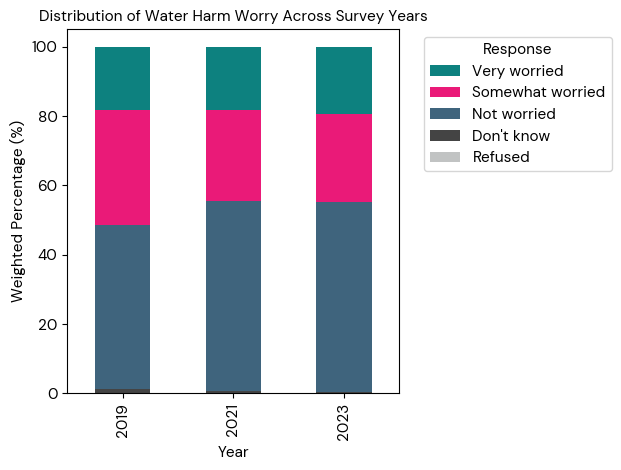

In [ ]:
# STACKED BAR PLOT OF WATER WORRY
colors=['#c1c3c3', '#444444', '#3f647d', '#ea1a78', '#0d817f', '#003f3f']
#wide format pivot table
pivot_waterworry =  water_worry_df.pivot(index='year', columns='water_harm_worry', values='percent')

#ensures year is treated as categorical variable for the years to be in order
water_worry_df['year'] = water_worry_df['year'].astype(str)

#column ordering
order = ['No Response', 'Refused', "Don't know", 'Not worried', 'Somewhat worried', 'Very worried']
pivot_waterworry = pivot_waterworry.reindex(columns=[c for c in order if c in pivot_waterworry.columns])

# plot stacked bar
ax = pivot_waterworry.plot(
    kind='bar',
    stacked=True,
    color=colors,
)

# Apply DM Sans font everywhere
ax.set_title("Distribution of Water Harm Worry Across Survey Years", fontproperties=font)
ax.set_ylabel('Weighted Percentage (%)', fontproperties=font)
ax.set_xlabel('Year', fontproperties=font)

# reorder legend to match visual stacking (top-to-bottom)
handles, labels = ax.get_legend_handles_labels()
handles = [handles[labels.index(o)] for o in order if o in labels]
labels = [o for o in order if o in labels]

# reverse order for top-to-bottom match
handles, labels = handles[::-1], labels[::-1]

# Legend with DM Sans font
ax.legend(
    handles,
    labels,
    title='Response',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    prop=font,
    title_fontproperties=font
)

# Apply DM Sans to tick labels
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(font)

plt.tight_layout()
plt.show()

In [ ]:
#PREDICTION 4 - HOW HAVE WORRY QUESTION RESPONSES CHANGED?
#checking indicator 3: crime

# Cleaning column
all_waves_df['crime_harm_worry'] = all_waves_df['crime_harm_worry'].replace(
    {'': 'No Response', ' ': 'No Response', '(DK)': "Don't know", '(Refused)': 'Refused'}
)

# Calculate distributions by year
crime_worry_results = []
for year, group in all_waves_df.groupby("year"):
    dist = weighted_distribution(group, "crime_harm_worry", "weight")
    dist["year"] = year
    crime_worry_results.append(dist)

crime_worry_df = pd.concat(crime_worry_results)

# Show long-format results
print(crime_worry_df)

# Pivot for easier comparison
pivot_crimeworry = crime_worry_df.pivot(index="crime_harm_worry", columns="year", values="percent")
print(pivot_crimeworry.round(1))

   crime_harm_worry        weight    percent  year
0        Don't know  2.029696e+08   3.785750  2019
1       Not worried  1.800032e+09  33.573854  2019
2           Refused  1.062541e+07   0.198183  2019
3  Somewhat worried  1.639948e+09  30.588000  2019
4      Very worried  1.707835e+09  31.854213  2019
0        Don't know  7.883005e+07   1.482794  2021
1       Not worried  2.150724e+09  40.455145  2021
2           Refused  5.500449e+06   0.103464  2021
3  Somewhat worried  1.397435e+09  26.285764  2021
4      Very worried  1.683828e+09  31.672833  2021
0        Don't know  1.955953e+03   1.331396  2023
1       Not worried  4.866163e+04  33.123429  2023
2           Refused  1.504024e+02   0.102377  2023
3  Somewhat worried  4.332779e+04  29.492747  2023
4      Very worried  5.281422e+04  35.950051  2023
year              2019  2021  2023
crime_harm_worry                  
Don't know         3.8   1.5   1.3
Not worried       33.6  40.5  33.1
Refused            0.2   0.1   0.1
Somewhat 

In [ ]:
#CRIME WORRY SUMS

worry_levels = ["Very worried", "Somewhat worried"]

totals = pivot_crimeworry.loc[worry_levels].sum()

for year, total in totals.items():
    print(f"In {year}, {total:.2f}% of respondents were worried in some capacity about harm from crime.")

In 2019, 62.44% of respondents were worried in some capacity about harm from crime.
In 2021, 57.96% of respondents were worried in some capacity about harm from crime.
In 2023, 65.44% of respondents were worried in some capacity about harm from crime.


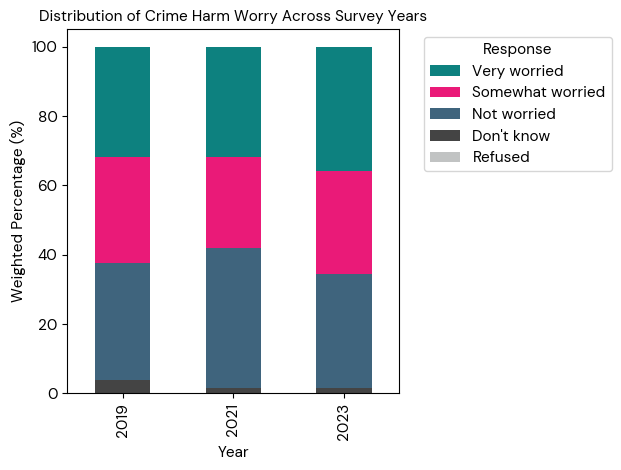

In [ ]:
# STACKED BAR PLOT OF CRIME WORRY
colors=['#c1c3c3', '#444444', '#3f647d', '#ea1a78', '#0d817f', '#003f3f']
#wide format pivot table
pivot_crimeworry =  crime_worry_df.pivot(index='year', columns='crime_harm_worry', values='percent')

#ensures year is treated as categorical variable for the years to be in order
crime_worry_df['year'] = crime_worry_df['year'].astype(str)

#column ordering
order = ['No Response', 'Refused', "Don't know", 'Not worried', 'Somewhat worried', 'Very worried']
pivot_crimeworry = pivot_crimeworry.reindex(columns=[c for c in order if c in pivot_crimeworry.columns])

# plot stacked bar
ax = pivot_crimeworry.plot(
    kind='bar',
    stacked=True,
    color=colors,
)

# Apply DM Sans font everywhere
ax.set_title("Distribution of Crime Harm Worry Across Survey Years", fontproperties=font)
ax.set_ylabel('Weighted Percentage (%)', fontproperties=font)
ax.set_xlabel('Year', fontproperties=font)

# reorder legend to match visual stacking (top-to-bottom)
handles, labels = ax.get_legend_handles_labels()
handles = [handles[labels.index(o)] for o in order if o in labels]
labels = [o for o in order if o in labels]

# reverse order for top-to-bottom match
handles, labels = handles[::-1], labels[::-1]

# Legend with DM Sans font
ax.legend(
    handles,
    labels,
    title='Response',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    prop=font,
    title_fontproperties=font
)

# Apply DM Sans to tick labels
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(font)

plt.tight_layout()
plt.show()

In [ ]:
all_waves_df['food_harm_experienced'].unique().tolist()

['Yes',
 'No',
 '(DK)',
 '(Refused)',
 'Both',
 'Yes, know someone who has experienced',
 'Yes, personally experienced']

In [ ]:
#PREDICTION 4 - HOW HAVE HARM EXPERIENCE QUESTION RESPONSES CHANGED?
#checking indicator 1: food

# Column cleaning
all_waves_df['food_harm_experienced'] = all_waves_df['food_harm_experienced'].replace({'Yes, personally experienced': 'Yes', 'Yes, know someone who has experienced': 'Yes', 'Both': 'Yes', '(DK)': "Don't know", '(Refused)': 'Refused'})
# unwanted_responses = ['(DK)', '(Refused)']
# all_waves_df = all_waves_df[~all_waves_df['food_harm_experienced'].isin(unwanted_responses)]

# Calculate distributions by year
food_experience_results = []
for year, group in all_waves_df.groupby("year"):
    dist = weighted_distribution(group, "food_harm_experienced", "weight")
    dist["year"] = year
    food_experience_results.append(dist)

food_experience_df = pd.concat(food_experience_results)

# Show long-format results
print(food_experience_df)

# Pivot for easier comparison
pivot_foodharm = food_experience_df.pivot(index="food_harm_experienced", columns="year", values="percent")
print(pivot_foodharm.round(1))


  food_harm_experienced        weight    percent  year
0            Don't know  1.112924e+08   2.075806  2019
1                    No  4.313770e+09  80.459621  2019
2               Refused  4.821789e+06   0.089935  2019
3                   Yes  9.315255e+08  17.374638  2019
0            Don't know  5.183017e+07   0.974926  2021
1                    No  4.260312e+09  80.136517  2021
2               Refused  3.056641e+06   0.057495  2021
3                   Yes  1.001119e+09  18.831062  2021
0            Don't know  1.131775e+03   0.770386  2023
1                    No  1.144284e+05  77.890136  2023
2               Refused  8.521500e+01   0.058005  2023
3                   Yes  3.126461e+04  21.281472  2023
year                   2019  2021  2023
food_harm_experienced                  
Don't know              2.1   1.0   0.8
No                     80.5  80.1  77.9
Refused                 0.1   0.1   0.1
Yes                    17.4  18.8  21.3


In [ ]:
# FOOD HARM 'YES' RESPONSES
harm_levels = ["Yes"]

totals = pivot_foodharm.loc[harm_levels].sum()

for year, total in totals.items():
    print(f"In {year}, {total:.2f}% of respondents either experienced harm in some capacity from the food they eat or know someone who did or both.")

In 2019, 17.37% of respondents either experienced harm in some capacity from the food they eat or know someone who did or both.
In 2021, 18.83% of respondents either experienced harm in some capacity from the food they eat or know someone who did or both.
In 2023, 21.28% of respondents either experienced harm in some capacity from the food they eat or know someone who did or both.


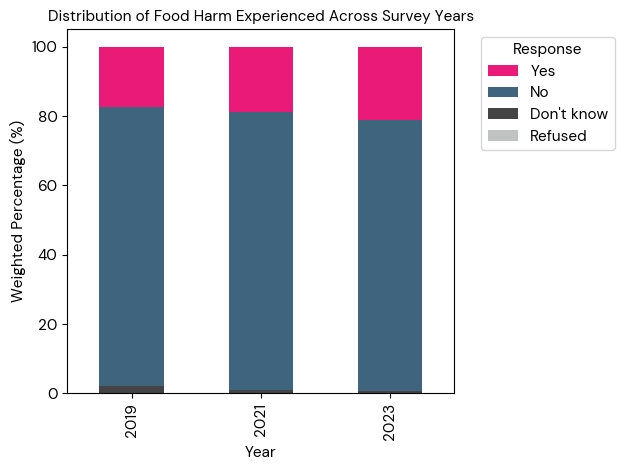

In [ ]:
# STACKED BAR PLOT OF FOOD HARM EXPERIENCED
colors=['#c1c3c3', '#444444', '#3f647d', '#ea1a78', '#0d817f', '#003f3f']
#wide format pivot table
pivot_foodharm =  food_experience_df.pivot(index='year', columns='food_harm_experienced', values='percent')

#ensures year is treated as categorical variable for the years to be in order
food_experience_df['year'] = food_experience_df['year'].astype(str)

#column ordering
order = ['Refused', "Don't know", 'No', 'Yes']
pivot_foodharm = pivot_foodharm.reindex(columns=[c for c in order if c in pivot_foodharm.columns])

# plot stacked bar
ax = pivot_foodharm.plot(
    kind='bar',
    stacked=True,
    color=colors,
)

# Apply DM Sans font everywhere
ax.set_title("Distribution of Food Harm Experienced Across Survey Years", fontproperties=font)
ax.set_ylabel('Weighted Percentage (%)', fontproperties=font)
ax.set_xlabel('Year', fontproperties=font)

# reorder legend to match visual stacking (top-to-bottom)
handles, labels = ax.get_legend_handles_labels()
handles = [handles[labels.index(o)] for o in order if o in labels]
labels = [o for o in order if o in labels]

# reverse order for top-to-bottom match
handles, labels = handles[::-1], labels[::-1]

# Legend with DM Sans font
ax.legend(
    handles,
    labels,
    title='Response',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    prop=font,
    title_fontproperties=font
)

# Apply DM Sans to tick labels
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(font)

plt.tight_layout()
plt.show()

In [ ]:
all_waves_df['water_harm_experienced'].unique().tolist()

['No',
 'Yes',
 '(DK)',
 '(Refused)',
 'Yes, know someone who has experienced',
 'Yes, personally experienced',
 'Both']

In [ ]:
#PREDICTION 4 - HOW HAVE HARM EXPERIENCE QUESTION RESPONSES CHANGED?
#checking indicator 2: water

# Column cleaning
all_waves_df['water_harm_experienced'] = all_waves_df['water_harm_experienced'].replace({'Yes, personally experienced': 'Yes', 'Yes, know someone who has experienced': 'Yes', 'Both': 'Yes', '(DK)': "Don't know", '(Refused)': 'Refused'})
# unwanted_responses = ['(DK)', '(Refused)']
# all_waves_df = all_waves_df[~all_waves_df['water_harm_experienced'].isin(unwanted_responses)]

# Calculate distributions by year
water_experience_results = []
for year, group in all_waves_df.groupby("year"):
    dist = weighted_distribution(group, "water_harm_experienced", "weight")
    dist["year"] = year
    water_experience_results.append(dist)

water_experience_df = pd.concat(water_experience_results)

# Show long-format results
print(water_experience_df)

# Pivot for easier comparison
pivot_waterharm = water_experience_df.pivot(index="water_harm_experienced", columns="year", values="percent")
print(pivot_waterharm.round(1))


  water_harm_experienced        weight    percent  year
0             Don't know  9.637528e+07   1.797574  2019
1                     No  4.497801e+09  83.892141  2019
2                Refused  2.619205e+06   0.048853  2019
3                    Yes  7.646138e+08  14.261433  2019
0             Don't know  4.692136e+07   0.882591  2021
1                     No  4.523293e+09  85.083198  2021
2                Refused  2.019897e+06   0.037994  2021
3                    Yes  7.440833e+08  13.996216  2021
0             Don't know  1.118139e+03   0.761104  2023
1                     No  1.242922e+05  84.604316  2023
2                Refused  9.342642e+01   0.063594  2023
3                    Yes  2.140623e+04  14.570985  2023
year                    2019  2021  2023
water_harm_experienced                  
Don't know               1.8   0.9   0.8
No                      83.9  85.1  84.6
Refused                  0.0   0.0   0.1
Yes                     14.3  14.0  14.6


In [ ]:
# WATER HARM 'YES' RESPONSES
harm_levels = ["Yes"]

totals = pivot_waterharm.loc[harm_levels].sum()

for year, total in totals.items():
    print(f"In {year}, {total:.2f}% of respondents either experienced harm in some capacity from the water they drink or know someone who did or both.")

In 2019, 14.26% of respondents either experienced harm in some capacity from the water they drink or know someone who did or both.
In 2021, 14.00% of respondents either experienced harm in some capacity from the water they drink or know someone who did or both.
In 2023, 14.57% of respondents either experienced harm in some capacity from the water they drink or know someone who did or both.


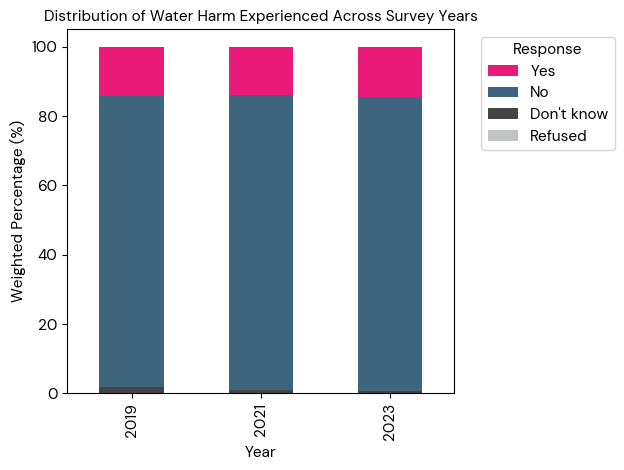

In [ ]:
# STACKED BAR PLOT OF WATER HARM EXPERIENCED
colors=['#c1c3c3', '#444444', '#3f647d', '#ea1a78', '#0d817f', '#003f3f']
#wide format pivot table
pivot_waterharm =  water_experience_df.pivot(index='year', columns='water_harm_experienced', values='percent')

#ensures year is treated as categorical variable for the years to be in order
water_experience_df['year'] = water_experience_df['year'].astype(str)

#column ordering
order = ['Refused', "Don't know", 'No', 'Yes']
pivot_waterharm = pivot_waterharm.reindex(columns=[c for c in order if c in pivot_waterharm.columns])

# plot stacked bar
ax = pivot_waterharm.plot(
    kind='bar',
    stacked=True,
    color=colors,
)

# Apply DM Sans font everywhere
ax.set_title("Distribution of Water Harm Experienced Across Survey Years", fontproperties=font)
ax.set_ylabel('Weighted Percentage (%)', fontproperties=font)
ax.set_xlabel('Year', fontproperties=font)

# reorder legend to match visual stacking (top-to-bottom)
handles, labels = ax.get_legend_handles_labels()
handles = [handles[labels.index(o)] for o in order if o in labels]
labels = [o for o in order if o in labels]

# reverse order for top-to-bottom match
handles, labels = handles[::-1], labels[::-1]

# Legend with DM Sans font
ax.legend(
    handles,
    labels,
    title='Response',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    prop=font,
    title_fontproperties=font
)

# Apply DM Sans to tick labels
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(font)

plt.tight_layout()
plt.show()

In [ ]:
#PREDICTION 4 - HOW HAVE HARM EXPERIENCE QUESTION RESPONSES CHANGED?
#checking indicator 3: crime

# Column cleaning
all_waves_df['crime_harm_experienced'] = all_waves_df['crime_harm_experienced'].replace({'Yes, personally experienced': 'Yes', 'Yes, know someone who has experienced': 'Yes', 'Both': 'Yes', '(DK)': "Don't know", '(Refused)': 'Refused'})
# unwanted_responses = ['(DK)', '(Refused)']
# all_waves_df = all_waves_df[~all_waves_df['crime_harm_experienced'].isin(unwanted_responses)]

# Calculate distributions by year
crime_experience_results = []
for year, group in all_waves_df.groupby("year"):
    dist = weighted_distribution(group, "crime_harm_experienced", "weight")
    dist["year"] = year
    crime_experience_results.append(dist)

crime_experience_df = pd.concat(crime_experience_results)

# Show long-format results
print(crime_experience_df)

# Pivot for easier comparison
pivot_crimeharm = crime_experience_df.pivot(index="crime_harm_experienced", columns="year", values="percent")
print(pivot_crimeharm.round(1))


  crime_harm_experienced        weight    percent  year
0             Don't know  1.363097e+08   2.542423  2019
1                     No  4.257170e+09  79.403937  2019
2                Refused  9.811669e+06   0.183005  2019
3                    Yes  9.581179e+08  17.870635  2019
0             Don't know  5.129625e+07   0.964883  2021
1                     No  4.231454e+09  79.593709  2021
2                Refused  3.196013e+06   0.060117  2021
3                    Yes  1.030371e+09  19.381291  2021
0             Don't know  1.301625e+03   0.886001  2023
1                     No  1.120069e+05  76.241839  2023
2                Refused  1.283779e+02   0.087385  2023
3                    Yes  3.347311e+04  22.784774  2023
year                    2019  2021  2023
crime_harm_experienced                  
Don't know               2.5   1.0   0.9
No                      79.4  79.6  76.2
Refused                  0.2   0.1   0.1
Yes                     17.9  19.4  22.8


In [ ]:
# CRIME HARM 'YES' RESPONSES
harm_levels = ["Yes"]

totals = pivot_crimeharm.loc[harm_levels].sum()

for year, total in totals.items():
    print(f"In {year}, {total:.2f}% of respondents either experienced harm in some capacity from crime or know someone who did or both.")

In 2019, 17.87% of respondents either experienced harm in some capacity from crime or know someone who did or both.
In 2021, 19.38% of respondents either experienced harm in some capacity from crime or know someone who did or both.
In 2023, 22.78% of respondents either experienced harm in some capacity from crime or know someone who did or both.


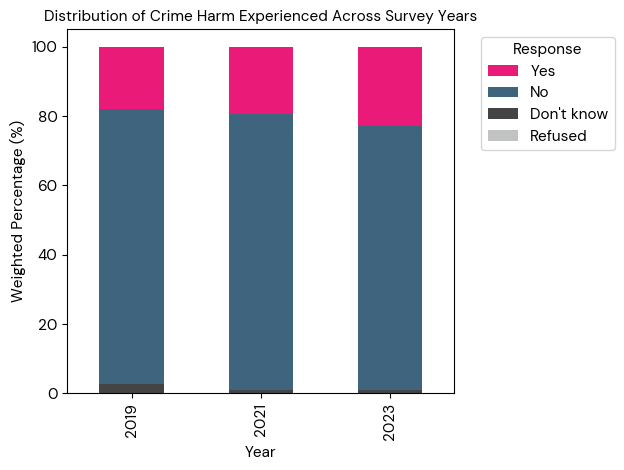

In [ ]:
# STACKED BAR PLOT OF CRIME HARM EXPERIENCED
colors=['#c1c3c3', '#444444', '#3f647d', '#ea1a78', '#0d817f', '#003f3f']
#wide format pivot table
pivot_crimeharm =  crime_experience_df.pivot(index='year', columns='crime_harm_experienced', values='percent')

#ensures year is treated as categorical variable for the years to be in order
crime_experience_df['year'] = crime_experience_df['year'].astype(str)

#column ordering
order = ['Refused', "Don't know", 'No', 'Yes']
pivot_crimeharm = pivot_crimeharm.reindex(columns=[c for c in order if c in pivot_crimeharm.columns])

# plot stacked bar
ax = pivot_crimeharm.plot(
    kind='bar',
    stacked=True,
    color=colors,
)

# Apply DM Sans font everywhere
ax.set_title("Distribution of Crime Harm Experienced Across Survey Years", fontproperties=font)
ax.set_ylabel('Weighted Percentage (%)', fontproperties=font)
ax.set_xlabel('Year', fontproperties=font)

# reorder legend to match visual stacking (top-to-bottom)
handles, labels = ax.get_legend_handles_labels()
handles = [handles[labels.index(o)] for o in order if o in labels]
labels = [o for o in order if o in labels]

# reverse order for top-to-bottom match
handles, labels = handles[::-1], labels[::-1]

# Legend with DM Sans font
ax.legend(
    handles,
    labels,
    title='Response',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    prop=font,
    title_fontproperties=font
)

# Apply DM Sans to tick labels
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(font)

plt.tight_layout()
plt.show()

In [ ]:
all_waves_df['work_injury'].unique().tolist()

[' ',
 'Yes',
 'No',
 '(DK)',
 '(Refused)',
 'Both',
 'Yes, personally experienced',
 'Yes, know someone who has experienced']

In [ ]:
# PREDICTION 5: Work Injuries are likely to inch upwards

# Cleaning
all_waves_df['work_injury'] = all_waves_df['work_injury'].replace({' ': 'No Response', 'Yes, personally experienced': 'Yes', 'Yes, know someone who has experienced': 'Yes', 'Both': 'Yes', '(DK)': "Don't know", '(Refused)': 'Refused'})
all_waves_df['year'] = pd.to_numeric(all_waves_df['year'], errors='coerce')
waves2021_2023df = all_waves_df[all_waves_df['year'] != 2019]

# Calculate distributions by year
work_injury_results = []
for year, group in waves2021_2023df.groupby("year"):
    dist = weighted_distribution(group, "work_injury", "weight")
    dist["year"] = year
    work_injury_results.append(dist)

work_injury_df = pd.concat(work_injury_results)

# Show long-format results
print(work_injury_df)

# Pivot for easier comparison
pivot_workinjury = work_injury_df.pivot(index="work_injury", columns="year", values="percent")
print(pivot_workinjury.round(1))

  work_injury        weight    percent  year
0  Don't know  5.147142e+07   0.968178  2021
1          No  3.981927e+09  74.900097  2021
2     Refused  5.827743e+06   0.109620  2021
3         Yes  1.277091e+09  24.022105  2021
0  Don't know  1.325497e+03   0.902251  2023
1          No  1.110857e+05  75.614817  2023
2     Refused  1.742425e+02   0.118605  2023
3         Yes  3.432453e+04  23.364326  2023
year         2021  2023
work_injury            
Don't know    1.0   0.9
No           74.9  75.6
Refused       0.1   0.1
Yes          24.0  23.4


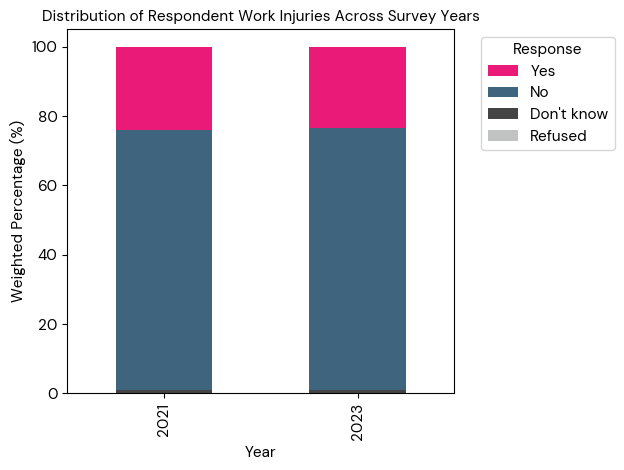

In [ ]:
# STACKED BAR PLOT OF WORK INJURIES EXPERIENCED
colors=['#c1c3c3', '#444444', '#3f647d', '#ea1a78', '#0d817f', '#003f3f']
#wide format pivot table
pivot_workinjury =  work_injury_df.pivot(index='year', columns='work_injury', values='percent')

#ensures year is treated as categorical variable for the years to be in order
work_injury_df['year'] = work_injury_df['year'].astype(str)

#column ordering
order = ['Refused', "Don't know", 'No', 'Yes']
pivot_workinjury = pivot_workinjury.reindex(columns=[c for c in order if c in pivot_workinjury.columns])

# plot stacked bar
ax = pivot_workinjury.plot(
    kind='bar',
    stacked=True,
    color=colors,
)

# Apply DM Sans font everywhere
ax.set_title("Distribution of Respondent Work Injuries Across Survey Years", fontproperties=font)
ax.set_ylabel('Weighted Percentage (%)', fontproperties=font)
ax.set_xlabel('Year', fontproperties=font)

# reorder legend to match visual stacking (top-to-bottom)
handles, labels = ax.get_legend_handles_labels()
handles = [handles[labels.index(o)] for o in order if o in labels]
labels = [o for o in order if o in labels]

# reverse order for top-to-bottom match
handles, labels = handles[::-1], labels[::-1]

# Legend with DM Sans font
ax.legend(
    handles,
    labels,
    title='Response',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    prop=font,
    title_fontproperties=font
)

# Apply DM Sans to tick labels
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(font)

plt.tight_layout()
plt.show()